In [242]:
%load_ext autoreload
%autoreload 2

In [1]:
# ruff: noqa

import numpy as np
import importlib
import matplotlib.pyplot as plt
import piecewise_regression
import statsmodels.api as sm
from scipy import stats
from scipy.signal import argrelmax

In [186]:
#import pyspoc.rstatistics.fractal.main as psfrac
import pyspoc.rstatistics.fractal.func as psfunc
import pyspoc.rstatistics.fractal.func_numba as psfuncn
import pyspoc.rstatistics.fractal.renyi as prenyi
import pyspoc.data.generators.fractal as psfgen

In [4]:
def sample_polyline(points: np.ndarray, points_per_segment: int = 10) -> np.ndarray:
    samples = []

    for p0, p1 in zip(points[:-1], points[1:]):
        t = np.linspace(0.0, 1.0, points_per_segment, endpoint=False)
        seg = (1.0 - t[:, None]) * p0 + t[:, None] * p1
        samples.append(seg)

    return np.vstack(samples)

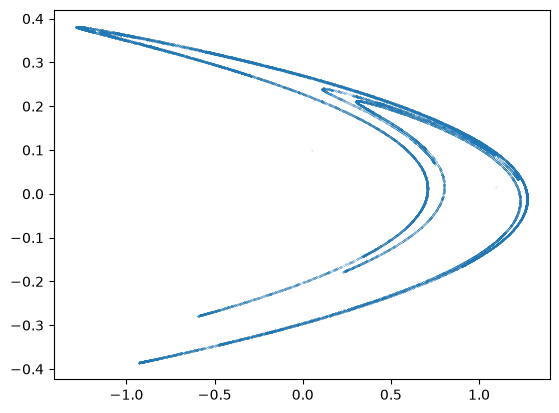

In [11]:
data = psfgen.henon()
plt.scatter(data[:,0], data[:,1], s=0.01)
plt.show()

In [164]:
psfunc._get_datseries_scale(data, psi=0, zeta=0, k=30)

array([1.66244082e+00, 9.18216559e-01, 5.07158895e-01, 2.80119262e-01,
       1.54718377e-01, 8.54556589e-02, 4.71997560e-02, 2.60698589e-02,
       1.43991749e-02, 7.95310165e-03, 4.39273961e-03, 2.42624351e-03,
       1.34008798e-03, 7.40171297e-04, 4.08819089e-04, 2.25803200e-04,
       1.24717966e-04, 6.88855207e-05, 3.80475654e-05, 2.10148260e-05,
       1.16071267e-05, 6.41096863e-06, 3.54097270e-06, 1.95578678e-06,
       1.08024044e-06, 5.96649606e-07, 3.29547700e-07, 1.82019204e-07,
       1.00534735e-07, 5.55283878e-08])

In [145]:
psfunc._get_default_scale(data)

array([1.66713118e+04, 1.57387332e+04, 1.48583223e+04, 1.40271608e+04,
       1.32424937e+04, 1.25017202e+04, 1.18023849e+04, 1.11421699e+04,
       1.05188866e+04, 9.93046934e+03, 9.37496758e+03, 8.85054011e+03,
       8.35544865e+03, 7.88805218e+03, 7.44680145e+03, 7.03023390e+03,
       6.63696878e+03, 6.26570256e+03, 5.91520465e+03, 5.58431329e+03,
       5.27193169e+03, 4.97702446e+03, 4.69861407e+03, 4.43577771e+03,
       4.18764420e+03, 3.95339105e+03, 3.73224182e+03, 3.52346348e+03,
       3.32636402e+03, 3.14029013e+03, 2.96462506e+03, 2.79878653e+03,
       2.64222486e+03, 2.49442112e+03, 2.35488539e+03, 2.22315516e+03,
       2.09879381e+03, 1.98138912e+03, 1.87055195e+03, 1.76591492e+03,
       1.66713118e+03, 1.57387332e+03, 1.48583223e+03, 1.40271608e+03,
       1.32424937e+03, 1.25017202e+03, 1.18023849e+03, 1.11421699e+03,
       1.05188866e+03, 9.93046934e+02, 9.37496758e+02, 8.85054011e+02,
       8.35544865e+02, 7.88805218e+02, 7.44680145e+02, 7.03023390e+02,
      

In [ ]:
scales = psfunc._get_datseries_scale(data, k=50, zeta=1)
neg_log_scales = -np.log(scales)

In [238]:
densities = prenyi._get_renyi_entropy_numba_fast(0, data, scales)

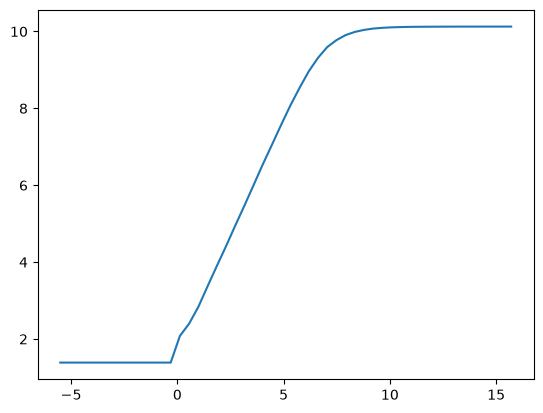

In [239]:
plt.plot(neg_log_scales, densities)

In [240]:
# Perform OLS regression of the scaling curve as starting point.
slope, adj_r2 = psfunc._compute_ols_results(neg_log_scales, densities)

# Perform iterative piecewise linear regression of scaling curve.
best_fit = psfunc._get_best_parsimonous_model_fit(
    neg_log_scales,
    densities,
    adj_r2,
    0.005)

# Get fitted linear segments from piecewise regression.
alphas, breakpoints = psfunc._get_segments(
    best_fit,
    neg_log_scales)

In [236]:
alphas

array([1.1781732 , 0.03697837])

In [241]:
# Trim elbows from linear segments.
trimmed_scales, trimmed_H = psfunc._trim_elbows(
    alphas,
    breakpoints,
    neg_log_scales,
    densities,
    0.25,
    recurse=True)

# Compute fractal dimension using Deshmukh method.
fd = psfunc._compute_deshmukh_slope_estimate(
    trimmed_scales,
    trimmed_H,
    0.25)

fd

1.206637228148414

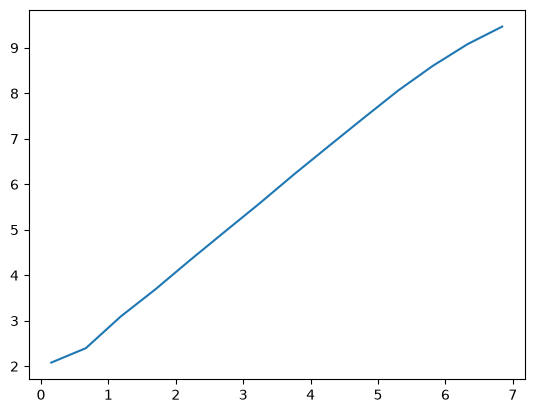

In [229]:
plt.plot(trimmed_scales, trimmed_H)

In [74]:
np.linalg.norm(data[1] - data[0], ord=2)

1.0499463081510407

In [75]:
np.linalg.norm(np.array([1,1]), ord=2)

1.4142135623730951

In [79]:
data_sample = data[:1000]
data_sample.shape

(1000, 2)

In [93]:
data_ord = psfuncn._sort_data(data_sample)

In [97]:
n = data_sample.shape[0]
dists = []

for i in range(1,n):
    for j in range(i+1, n):
        dist = np.linalg.norm(data[i] - data[j], ord=2)
        dists.append(dist)

In [98]:
np.array(dists).min()

4.3607559785572596e-05

In [94]:
np.min(np.linalg.norm(data_ord[:-1, :] - data_ord[1:, :], axis=1))

4.3607559785572596e-05

In [89]:
data.max(axis=0)

array([1.27297352, 0.38189206])

In [ ]:
renyi = prenyi.RenyiEntropy(q=2, debug_numba="raise")
calculated_fd = renyi.compute(data)
print(calculated_fd)

Numba ran _get_renyi_entropy_numba successfully.
1.4264557703455958


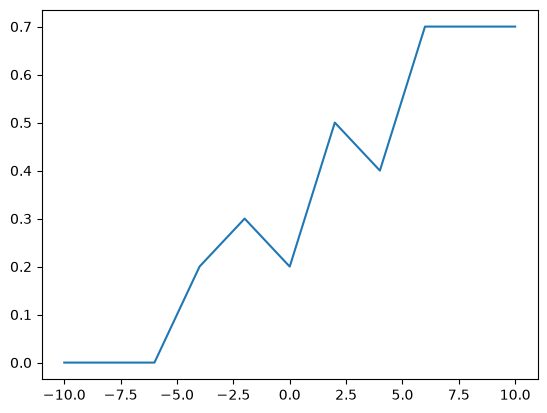

In [3]:
H = np.array([0.0, 0.0, 0.0, 0.2, 0.3, 0.2, 0.5, 0.4, 0.7, 0.7, 0.7])
neg_log_scales = np.linspace(-10, 10, 11)
plt.plot(neg_log_scales, H)
plt.show()

In [17]:
weird = sm.add_constant(neg_log_scales)
ols = sm.OLS(H, weird)
results = ols.fit()
results.params

array([0.33636364, 0.04090909])

In [21]:
n = H.shape[0]
p = 1
tss = H.var() * n
rss = results.ssr
r_sq = 1 - rss / tss
adj_r_sq = 1 - (n - 1) / (n - 1 - p) * (1 - r_sq)
adj_r_sq

0.9046902432906948

In [22]:
results.rsquared_adj

0.9046902432906948

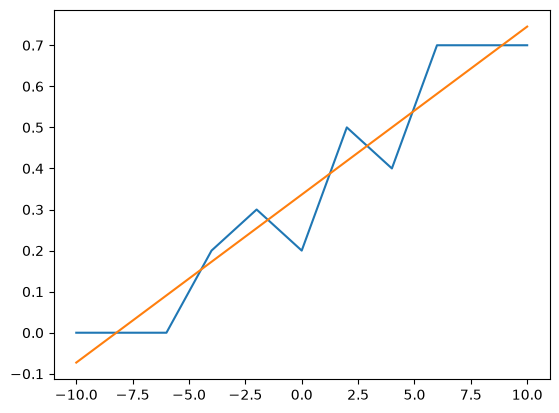

In [ ]:
x_line = np.linspace(neg_log_scales.min(), neg_log_scales.max(), 100)
y_line = intercept + slope * x_line
plt.plot(neg_log_scales, H)
plt.plot(x_line, y_line)
plt.show()

In [ ]:
H[3:9]

array([0.2, 0.3, 0.2, 0.5, 0.4, 0.7])

In [121]:
trimmed_scales = neg_log_scales[3:9]
trimmed_H = H[3:9]
prop_window_size = 0.2

weights = psfunc._compute_deshmukh_slope_estimate(trimmed_scales,
                                                 trimmed_H,
                                                 prop_window_size)

weights

0.025461438945955504

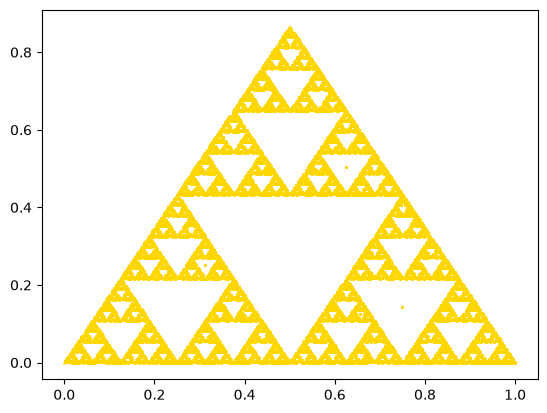

In [3]:
data = psfgen.sierpinski(iters=25000)
plt.plot(*data.T, 'o', color="gold", ms=1)

In [ ]:
scales = psfunc._get_default_scale(data)

Numba ran _get_default_init_scale successfully.


In [6]:
H = prenyi._get_renyi_entropy_numba(3, data, scales)

In [5]:
H = prenyi._get_renyi_entropy_py(3, data, scales)

In [10]:
H = prenyi._get_renyi_entropy(3, data, scales, debug_numba="raise")

Numba ran _get_renyi_entropy_numba successfully.


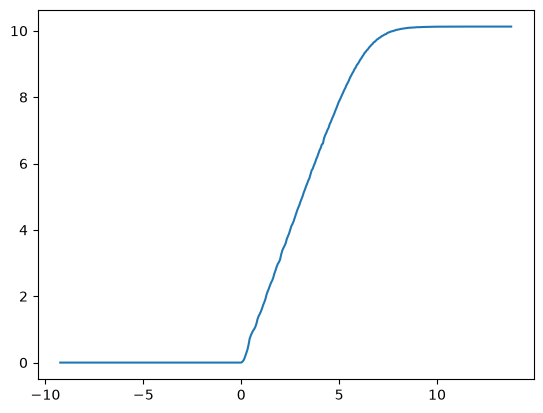

In [11]:
H = prenyi._get_renyi_entropy(3, data, scales)
neg_log_scales = -np.log(scales)
plt.plot(neg_log_scales, H)
#best_fit = psfunc._get_best_parsimonous_model_fit(neg_log_scales, H_numba, 0.02)
#alphas, breakpoints = psfunc._get_pieces(best_fit, neg_log_scales)

In [97]:
importlib.reload(psfgen)

<module 'pyspoc.data.generators.fractal' from '/home/gsc225/Projects/hcda/py-spoc/pyspoc/data/generators/fractal.py'>

In [101]:
data, fd = psfgen.mandelbrot(iters=25, res=2000)

In [102]:
data.shape

(421776, 2)

In [77]:
np.array(2)

array(2)

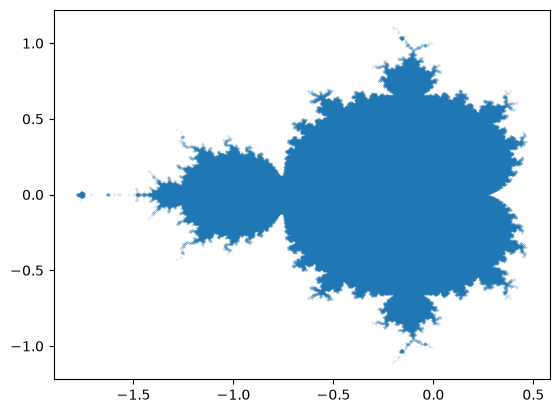

In [103]:
plt.scatter(data[:,0], data[:,1], s=0.005)
plt.show()

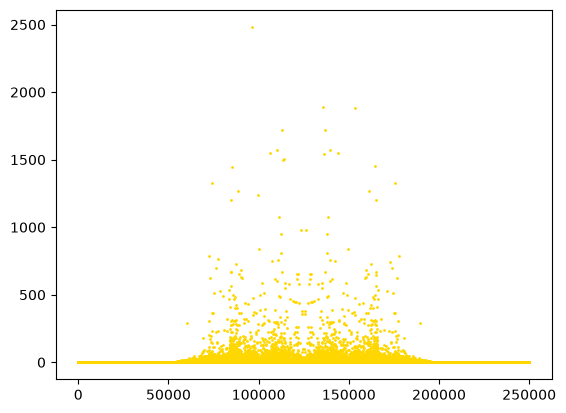

In [ ]:
H = prenyi._get_renyi_entropy(3, data, scales)
neg_log_scales = -np.log(scales)
plt.plot(neg_log_scales, H)

In [1]:
print("test")

test


In [1]:
import numpy as np

import pyspoc.rstatistics.fractal.renyi as prenyi
import pyspoc.rstatistics.fractal.func_numba as fnumba

rng = np.random.default_rng(0)
data = rng.random((100, 100))
scales = np.exp(np.linspace(-10, 10, 11))

Traceback (most recent call last):
  File "/home/gsc225/Projects/hcda/py-spoc/.venv/lib/python3.12/site-packages/oct2py/__init__.py", line 55, in <module>
    octave = Oct2Py()
             ^^^^^^^^
  File "/home/gsc225/Projects/hcda/py-spoc/.venv/lib/python3.12/site-packages/oct2py/core.py", line 249, in __init__
    self.restart()
  File "/home/gsc225/Projects/hcda/py-spoc/.venv/lib/python3.12/site-packages/oct2py/core.py", line 999, in restart
    raise Oct2PyError(str(e)) from None
oct2py.utils.Oct2PyError: octave not found, please see README


oct2py: failed to create default session: octave not found, please see README
Octave not available: octave not found, please see README
Starting JVM with java class /home/gsc225/Projects/hcda/py-spoc/pyspoc/lib/jidt/infodynamics.jar.
Jpype JVM not available: No JVM shared library file (libjvm.so) found. Try setting up the JAVA_HOME environment variable properly.


In [5]:
H = prenyi._get_renyi_entropy(0, data, scales, 1e-6)
H

array([4.60517019, 4.60517019, 4.60517019, 4.60517019, 4.60517019,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        ])

In [3]:
H = prenyi._get_renyi_entropy_py(0, data, scales, 1e-6)
H

array([4.60517019, 4.60517019, 4.60517019, 4.60517019, 4.60517019,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        ])

In [ ]:
from numba import njit

@njit(boundscheck=True)
def _get_renyi_entropy(q: float,
                       data: np.ndarray,
                       scales: np.ndarray,
                       shannon_entropy_tol: float = 1e-6) -> np.ndarray:
    
    n_scales = scales.shape[0]
    n = data.shape[0]
    p = data.shape[1]
    H = np.empty(shape=n_scales, dtype=np.float64)

    for k in range(n_scales):
        #cnts = np.zeros((n, p+1), dtype=np.int32)
        cnts = np.zeros(n+1, dtype=np.int32)
        s = scales[k]

        # Get boxes containing each point.
        box_ids = np.floor(data / s).astype(np.int32)

        # Sort boxes.
        box_ids = fnumba._sort_data(box_ids)

        # Initialise previous box array.
        prev_box_id = np.zeros(shape=p).astype(np.int32)
        j = 0

        # Loop through all points.
        for i in range(n):

            # Get the box containing the point.
            box_id = box_ids[i]
            
            # If a different box than before, move on
            # to the next box.
            if np.any(prev_box_id != box_id):                
                prev_box_id[:] = box_id
                j += 1
            
            # Add a point count to the current box.
            cnts[j] += 1
                
        cnts = cnts[cnts > 0]

        if q == 0:
            H[k] = np.log(cnts.shape[0])
            continue

        probs = cnts / cnts.sum()

        if abs(q-1) < shannon_entropy_tol:
            H[k] = -np.sum(probs * np.log(probs))
            continue

        H[k] = np.log(np.sum(probs ** q)) / (1 - q)

    return cnts

In [3]:
data[:,1:2]

array([[0.26978671],
       [0.23237292],
       [0.18750772],
       [0.58332005],
       [0.93790511],
       [0.87522825],
       [0.72116579],
       [0.01454163],
       [0.6209089 ],
       [0.55060788],
       [0.82776292],
       [0.56667829],
       [0.37412689],
       [0.34765774],
       [0.27874716],
       [0.65633781],
       [0.89125108],
       [0.16990601],
       [0.55851365],
       [0.09677339],
       [0.06004126],
       [0.37927935],
       [0.48738459],
       [0.81494954],
       [0.14523164],
       [0.12759522],
       [0.71062536],
       [0.06826853],
       [0.29449927],
       [0.55123841],
       [0.79497039],
       [0.10155259],
       [0.56192469],
       [0.8046939 ],
       [0.2225466 ],
       [0.96194719],
       [0.23989896],
       [0.34076982],
       [0.96692218],
       [0.11759326],
       [0.51232998],
       [0.64343502],
       [0.257773  ],
       [0.79778933],
       [0.06924202],
       [0.91967919],
       [0.6969596 ],
       [0.558

In [4]:
scales

array([4.53999298e-05, 3.35462628e-04, 2.47875218e-03, 1.83156389e-02,
       1.35335283e-01, 1.00000000e+00, 7.38905610e+00, 5.45981500e+01,
       4.03428793e+02, 2.98095799e+03, 2.20264658e+04])

In [3]:
data[1:5,:].shape

(4, 100)

In [7]:
_get_renyi_entropy(0, data, scales, 1e-6)

array([100], dtype=int32)

In [33]:
from itertools import product

grid_A, grid_B = np.meshgrid(data[0], data[1], indexing='ij')
cartesian_product = np.column_stack([grid_A.ravel(), grid_B.ravel()])
cartesian_product.shape

(250000, 2)